# Nivel 1: Simulación numérica con datos sintéticos -> Nivel 1.1: PCA en 2D para visualizar Eigenfaces

## Paso 1: Importar librerías y crear datos sintéticos

Objetivo

Entender cómo PCA encuentra las direcciones principales (Eigenfaces) en un conjunto de datos.

Matemática que aprenderás
* Media y centrado de datos
*  Matriz de covarianza
*  Autovalores y autovectores
* Visualización de componentes principales


Paso 1: Importar librerías y crear datos sintéticos

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Configurar para ver resultados
np.random.seed(42)  # Para que los resultados sean reproducibles

# Crear datos sintéticos: 50 puntos que representan "rostros" en 2D
# Cada punto tiene dos características (ej. intensidad de dos píxeles)

# Primera característica: valores alrededor de 100 con variación
x = np.random.normal(100, 15, 50)

# Segunda característica: relacionada con la primera + algo de ruido
# Esto simula correlación entre píxeles (ej. si un píxel es oscuro, el vecino también)
y = x * 0.8 + np.random.normal(0, 8, 50)

# Organizar en matriz de datos (cada fila = un rostro, cada columna = una característica)
datos = np.column_stack([x, y])

print("Forma de la matriz de datos:", datos.shape)
print("Primeros 5 rostros (en 2D):")
print(datos[:5])

Forma de la matriz de datos: (50, 2)
Primeros 5 rostros (en 2D):
[[107.4507123   88.55324159]
 [ 97.92603548  75.26017014]
 [109.71532807  82.35688645]
 [122.84544785 103.16976859]
 [ 96.48769938  85.43815568]]


Explicación:

Creamos 50 puntos (rostros) con 2 características (píxeles).

Las características están correlacionadas (si x aumenta, y tiende a aumentar).

Esto simula la redundancia que hay en imágenes reales.

## Paso 2: Visualizar los datos originales

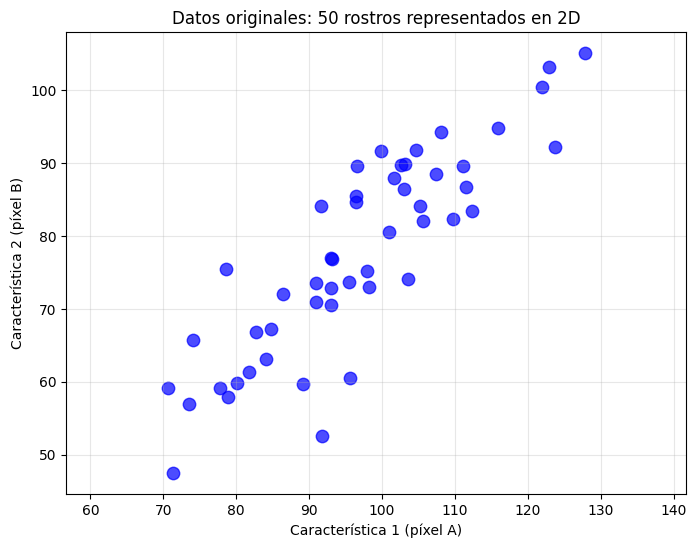

In [5]:
# Graficar los puntos originales
plt.figure(figsize=(8, 6))
plt.scatter(datos[:, 0], datos[:, 1], alpha=0.7, color='blue', s=80)
plt.xlabel('Característica 1 (píxel A)')
plt.ylabel('Característica 2 (píxel B)')
plt.title('Datos originales: 50 rostros representados en 2D')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

Explicación:

Cada punto azul es un "rostro" con dos valores (dos píxeles).

Los puntos están correlacionados: forman una nube alargada.

Queremos encontrar la dirección de mayor variación (eje principal).



## Paso 3: Calcular la media y centrar los datos

Media (rostro promedio): [96.61789142 77.4365601 ]


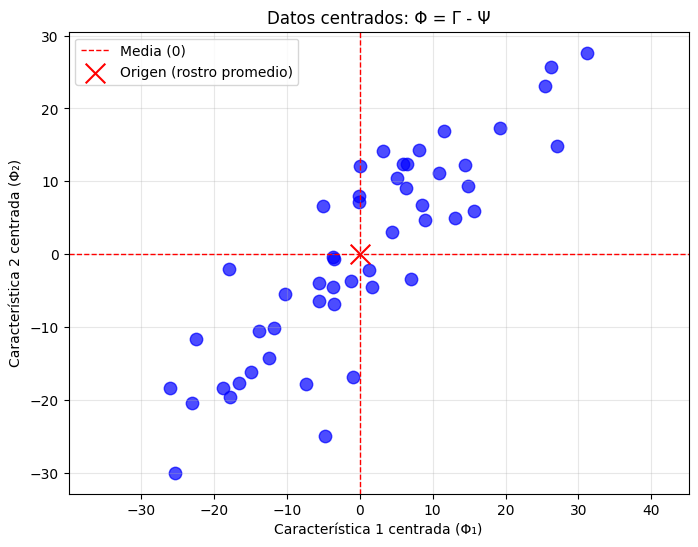

In [6]:
# Calcular la media de cada característica
media = np.mean(datos, axis=0)
print("Media (rostro promedio):", media)

# Centrar los datos: restar la media
datos_centrados = datos - media

# Graficar datos centrados
plt.figure(figsize=(8, 6))
plt.scatter(datos_centrados[:, 0], datos_centrados[:, 1], alpha=0.7, color='blue', s=80)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Media (0)')
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.scatter(0, 0, color='red', s=200, marker='x', label='Origen (rostro promedio)')
plt.xlabel('Característica 1 centrada (Φ₁)')
plt.ylabel('Característica 2 centrada (Φ₂)')
plt.title('Datos centrados: Φ = Γ - Ψ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

Explicación:

La media (Ψ) es el "rostro promedio".

Restamos la media para obtener Φ = Γ - Ψ.

Esto elimina la información común y deja solo los rasgos distintivos.

El origen (0,0) ahora representa el rostro promedio.

## Paso 4: Calcular la matriz de covarianza


In [7]:
# Calcular la matriz de covarianza
# Fórmula: C = (1/(n-1)) * X^T * X
n_muestras = len(datos_centrados)
C = (datos_centrados.T @ datos_centrados) / (n_muestras - 1)

print("Matriz de covarianza:")
print(C)
print("\nInterpretación:")
print(f"- C[0,0] = {C[0,0]:.2f} es la varianza de la característica 1")
print(f"- C[1,1] = {C[1,1]:.2f} es la varianza de la característica 2")
print(f"- C[0,1] = {C[0,1]:.2f} es la covarianza entre características")

Matriz de covarianza:
[[196.14091371 167.69531832]
 [167.69531832 191.70675229]]

Interpretación:
- C[0,0] = 196.14 es la varianza de la característica 1
- C[1,1] = 191.71 es la varianza de la característica 2
- C[0,1] = 167.70 es la covarianza entre características


Explicación:

La matriz de covarianza resume cómo varían juntas las características.

Valores grandes en la diagonal indican características con mucha variación.

Valores fuera de la diagonal indican correlación entre características.

## Paso 5: Calcular autovalores y autovectores


In [8]:
# Calcular autovalores y autovectores
autovalores, autovectores = np.linalg.eig(C)

# Ordenar de mayor a menor
idx = autovalores.argsort()[::-1]
autovalores = autovalores[idx]
autovectores = autovectores[:, idx]

print("Autovalores (λ):", autovalores)
print("\nAutovectores (v):")
print(autovectores)

print("\nInterpretación:")
print(f"- Primer autovalor λ₁ = {autovalores[0]:.2f} (varianza en la dirección principal)")
print(f"- Segundo autovalor λ₂ = {autovalores[1]:.2f} (varianza en la dirección secundaria)")
print(f"- El primer autovector v₁ = {autovectores[:,0]} es la dirección de máxima varianza")

Autovalores (λ): [361.63380656  26.21385944]

Autovectores (v):
[[ 0.71176532 -0.70241735]
 [ 0.70241735  0.71176532]]

Interpretación:
- Primer autovalor λ₁ = 361.63 (varianza en la dirección principal)
- Segundo autovalor λ₂ = 26.21 (varianza en la dirección secundaria)
- El primer autovector v₁ = [0.71176532 0.70241735] es la dirección de máxima varianza


Explicación:

Los autovalores indican cuánta varianza hay en cada dirección.

Los autovectores son las direcciones principales (Eigenfaces).

El primer autovector apunta hacia donde los datos varían más.

## Paso 6: Visualizar los componentes principales


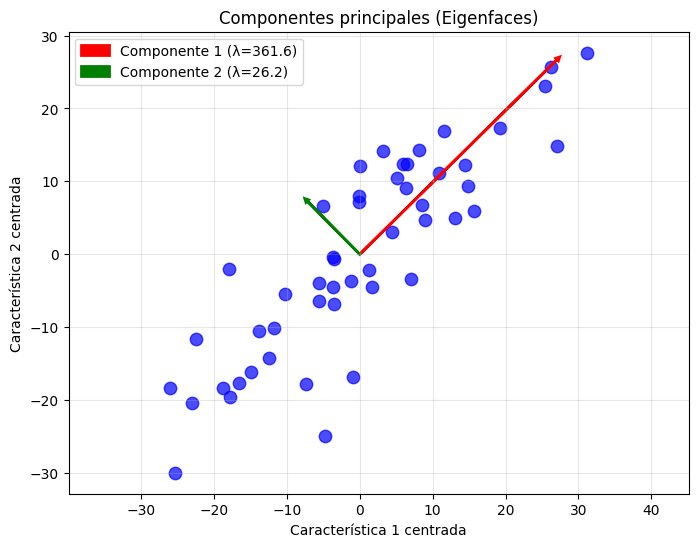

In [9]:
plt.figure(figsize=(8, 6))

# Graficar puntos centrados
plt.scatter(datos_centrados[:, 0], datos_centrados[:, 1], alpha=0.7, color='blue', s=80)

# Dibujar componentes principales como flechas desde el origen
for i in range(2):
    # Multiplicar por autovalor para escalar la flecha
    escala = np.sqrt(autovalores[i]) * 2  # *2 para hacerla más visible
    v = autovectores[:, i] * escala

    plt.arrow(0, 0, v[0], v[1],
              color='red' if i == 0 else 'green',
              head_width=0.5, head_length=0.5,
              linewidth=2,
              label=f'Componente {i+1} (λ={autovalores[i]:.1f})')

plt.xlabel('Característica 1 centrada')
plt.ylabel('Característica 2 centrada')
plt.title('Componentes principales (Eigenfaces)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

Explicación:

La flecha roja (Componente 1) es la dirección de máxima varianza.

La flecha verde (Componente 2) es perpendicular (segunda dirección).

Los datos se extienden más a lo largo de la dirección roja.



## Paso 7: Calcular la varianza explicada


Varianza explicada por cada componente:
Componente 1: 93.2%
Componente 2: 6.8%

Las primeras 2 componentes explican 100.0% de la varianza total


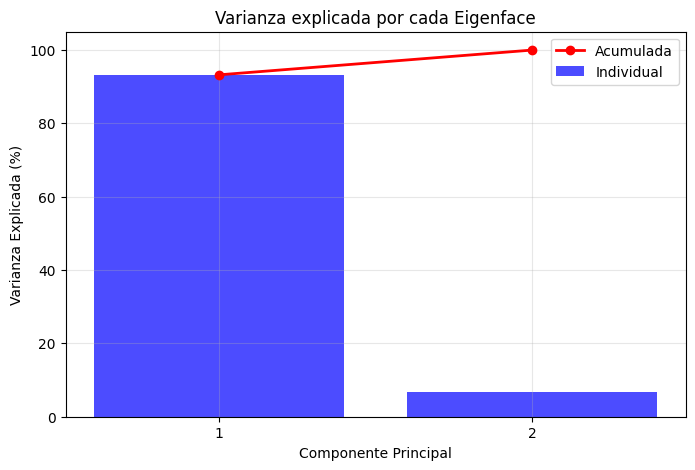

In [10]:
# Calcular porcentaje de varianza explicada por cada componente
varianza_explicada = autovalores / np.sum(autovalores) * 100
varianza_acumulada = np.cumsum(varianza_explicada)

print("Varianza explicada por cada componente:")
for i, var in enumerate(varianza_explicada):
    print(f"Componente {i+1}: {var:.1f}%")

print(f"\nLas primeras 2 componentes explican {varianza_acumulada[1]:.1f}% de la varianza total")

# Graficar varianza explicada
plt.figure(figsize=(8, 5))
plt.bar([1, 2], varianza_explicada, alpha=0.7, color='blue', label='Individual')
plt.plot([1, 2], varianza_acumulada, 'ro-', linewidth=2, label='Acumulada')
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada (%)')
plt.title('Varianza explicada por cada Eigenface')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks([1, 2])
plt.show()

Explicación:

En este ejemplo 2D, las dos componentes explican el 100% de la varianza.

En imágenes reales, las primeras 50-100 Eigenfaces pueden explicar más del 95%.

Esto permite reducir dimensionalidad sin perder información importante.

## Paso 8: Proyectar datos en las componentes principales


Datos originales (50 rostros, 2 dimensiones): (50, 2)
Datos proyectados (50 rostros, 1 dimensión): (50, 1)


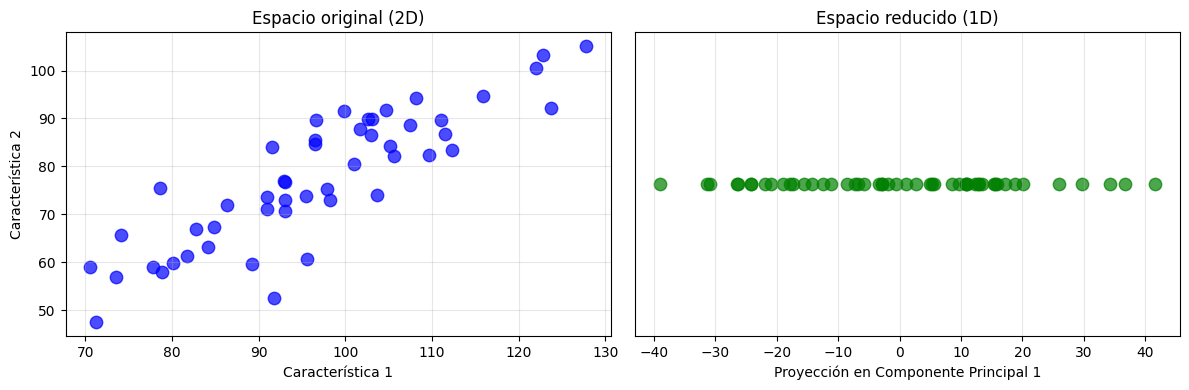

In [11]:
# Proyectar los datos en la primera componente principal
# Esto es equivalente a "comprimir" cada rostro a una sola dimensión
k = 1  # Número de componentes a conservar
Vk = autovectores[:, :k]
datos_proyectados = datos_centrados @ Vk

print("Datos originales (50 rostros, 2 dimensiones):", datos.shape)
print("Datos proyectados (50 rostros, 1 dimensión):", datos_proyectados.shape)

# Visualizar la proyección
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(datos[:, 0], datos[:, 1], alpha=0.7, color='blue', s=80)
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.title('Espacio original (2D)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(datos_proyectados, np.zeros_like(datos_proyectados), alpha=0.7, color='green', s=80)
plt.xlabel('Proyección en Componente Principal 1')
plt.yticks([])
plt.title('Espacio reducido (1D)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Explicación:

La proyección reduce la dimensionalidad de 2D a 1D.

Cada rostro ahora se representa con un solo número.

Esta es la esencia de Eigenfaces: comprimir imágenes manteniendo la información más relevante.

# Nivel 1: Simulación numérica con datos sintéticos -> Nivel 1.2: Similitud coseno en 3D.

Objetivo
Entender cómo la similitud entre dos rostros se mide por el ángulo entre sus vectores en la hiperesfera unitaria.

Matemática que aprenderás

* Normalización de vectores (proyección en hiperesfera)

* Producto escalar

* Relación entre ángulo y similitud coseno

* Visualización en 3D

## Paso 1: Importar librerías y crear vectores


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Configurar para que los resultados sean reproducibles
np.random.seed(42)

# Crear tres vectores que representan embeddings de rostros
# En un sistema real, estos vectores tendrían 128, 256 o 512 dimensiones
# Aquí usamos 3D para poder visualizarlos

# Rostro A (persona 1, primera foto)
v1 = np.array([0.8, 0.6, 0.2])

# Rostro A (misma persona, otra foto) - debería ser similar
v2 = np.array([0.7, 0.5, 0.3])

# Rostro B (otra persona) - debería ser diferente
v3 = np.array([-0.2, 0.1, 0.9])

print("Vectores originales (embeddings sin normalizar):")
print(f"v1 (Rostro A, foto 1): {v1}")
print(f"v2 (Rostro A, foto 2): {v2}")
print(f"v3 (Rostro B): {v3}")

Vectores originales (embeddings sin normalizar):
v1 (Rostro A, foto 1): [0.8 0.6 0.2]
v2 (Rostro A, foto 2): [0.7 0.5 0.3]
v3 (Rostro B): [-0.2  0.1  0.9]


Explicación:

Cada vector representa un rostro en un espacio de 3 dimensiones

En la práctica, los embeddings tienen cientos de dimensiones

v1 y v2 deberían ser similares (misma persona)

v3 debería ser diferente (otra persona)

## Paso 2: Normalizar vectores (proyección en hiperesfera)


In [13]:
def normalizar(v):
    """Normaliza un vector para que tenga norma = 1"""
    norma = np.linalg.norm(v)
    return v / norma, norma

# Normalizar cada vector
v1_norm, norm1 = normalizar(v1)
v2_norm, norm2 = normalizar(v2)
v3_norm, norm3 = normalizar(v3)

print("Vectores normalizados (viven en la esfera unitaria):")
print(f"v1_norm = {v1_norm} (norma original: {norm1:.3f})")
print(f"v2_norm = {v2_norm} (norma original: {norm2:.3f})")
print(f"v3_norm = {v3_norm} (norma original: {norm3:.3f})")

# Verificar que tienen norma 1
print(f"\nNorma de v1_norm: {np.linalg.norm(v1_norm):.3f}")
print(f"Norma de v2_norm: {np.linalg.norm(v2_norm):.3f}")
print(f"Norma de v3_norm: {np.linalg.norm(v3_norm):.3f}")

Vectores normalizados (viven en la esfera unitaria):
v1_norm = [0.78446454 0.58834841 0.19611614] (norma original: 1.020)
v2_norm = [0.76834982 0.5488213  0.32929278] (norma original: 0.911)
v3_norm = [-0.21566555  0.10783277  0.97049496] (norma original: 0.927)

Norma de v1_norm: 1.000
Norma de v2_norm: 1.000
Norma de v3_norm: 1.000


Explicación:

La normalización proyecta los vectores en la superficie de la esfera unitaria

Esto elimina la dependencia de la intensidad (magnitud)

La similitud depende solo de la dirección (ángulo)

## Paso 3: Calcular similitud coseno


In [14]:
# Similitud coseno = producto escalar después de normalizar
cos_sim_12 = np.dot(v1_norm, v2_norm)  # v1 vs v2 (misma persona)
cos_sim_13 = np.dot(v1_norm, v3_norm)  # v1 vs v3 (persona diferente)

# Calcular ángulos en grados
angulo_12 = np.arccos(cos_sim_12) * 180 / np.pi
angulo_13 = np.arccos(cos_sim_13) * 180 / np.pi

print("Resultados de similitud:")
print(f"v1 vs v2 (misma persona):")
print(f"  - Similitud coseno: {cos_sim_12:.4f}")
print(f"  - Ángulo: {angulo_12:.1f}°")
print(f"\nv1 vs v3 (persona diferente):")
print(f"  - Similitud coseno: {cos_sim_13:.4f}")
print(f"  - Ángulo: {angulo_13:.1f}°")

print("\nInterpretación:")
print("- Similitud cercana a 1 → ángulo pequeño → rostros similares")
print("- Similitud cercana a 0 → ángulo ≈ 90° → rostros diferentes")
print("- Similitud negativa → ángulo > 90° → muy diferentes")

Resultados de similitud:
v1 vs v2 (misma persona):
  - Similitud coseno: 0.9902
  - Ángulo: 8.0°

v1 vs v3 (persona diferente):
  - Similitud coseno: 0.0846
  - Ángulo: 85.1°

Interpretación:
- Similitud cercana a 1 → ángulo pequeño → rostros similares
- Similitud cercana a 0 → ángulo ≈ 90° → rostros diferentes
- Similitud negativa → ángulo > 90° → muy diferentes


Explicación:

La similitud coseno mide el ángulo entre dos vectores

Valor 1: vectores idénticos (mismo rostro)

Valor 0: vectores perpendiculares (no relacionados)

Valor -1: vectores opuestos (totalmente diferentes)



## Paso 4: Visualizar vectores en la esfera unitaria 3D


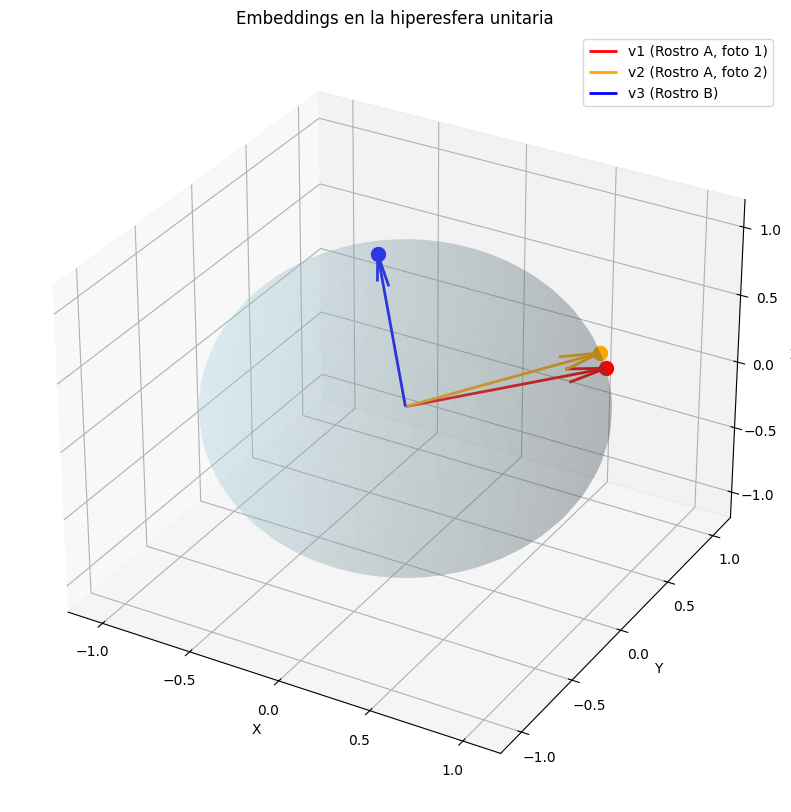

In [15]:
# Crear figura 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Dibujar la esfera unitaria
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 50)
x_esfera = np.outer(np.cos(u), np.sin(v))
y_esfera = np.outer(np.sin(u), np.sin(v))
z_esfera = np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x_esfera, y_esfera, z_esfera, color='lightblue', alpha=0.2, edgecolor='none')

# Dibujar los vectores desde el origen
ax.quiver(0, 0, 0, v1_norm[0], v1_norm[1], v1_norm[2],
          color='red', linewidth=2, arrow_length_ratio=0.2, label='v1 (Rostro A, foto 1)')
ax.quiver(0, 0, 0, v2_norm[0], v2_norm[1], v2_norm[2],
          color='orange', linewidth=2, arrow_length_ratio=0.2, label='v2 (Rostro A, foto 2)')
ax.quiver(0, 0, 0, v3_norm[0], v3_norm[1], v3_norm[2],
          color='blue', linewidth=2, arrow_length_ratio=0.2, label='v3 (Rostro B)')

# Marcar los puntos en la esfera
ax.scatter(v1_norm[0], v1_norm[1], v1_norm[2], color='red', s=100)
ax.scatter(v2_norm[0], v2_norm[1], v2_norm[2], color='orange', s=100)
ax.scatter(v3_norm[0], v3_norm[1], v3_norm[2], color='blue', s=100)

# Configurar ejes
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Embeddings en la hiperesfera unitaria')
ax.legend()

plt.show()

Explicación:

Los vectores viven en la superficie de la esfera (norma = 1)

v1 y v2 están cerca (ángulo pequeño)

v3 está lejos (ángulo grande)

## Paso 5: Visualizar los ángulos


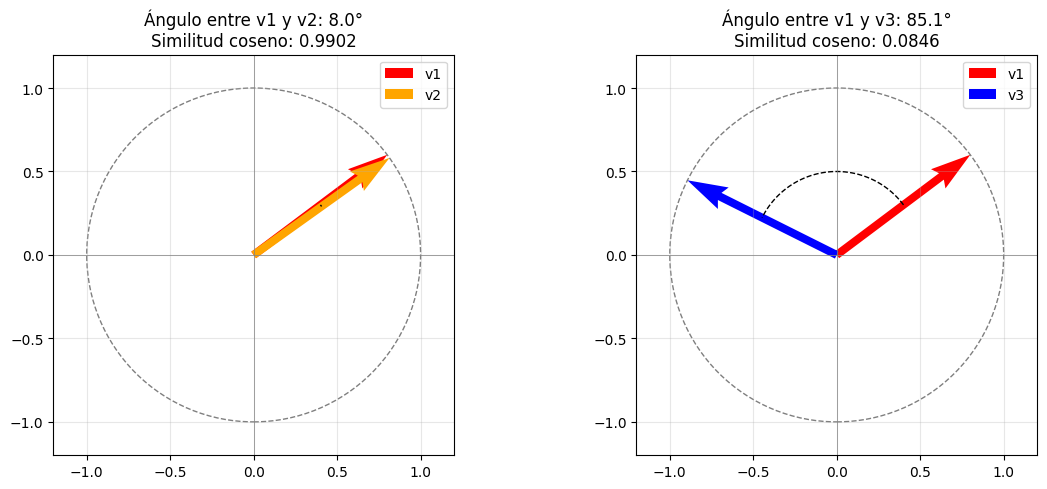

In [16]:
# Crear figura para visualizar los ángulos entre vectores
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Vista 2D para el ángulo entre v1 y v2 (proyección en plano XY)
ax1 = axes[0]
# Proyectar v1 y v2 en el plano XY
v1_xy = v1_norm[:2] / np.linalg.norm(v1_norm[:2])
v2_xy = v2_norm[:2] / np.linalg.norm(v2_norm[:2])

# Dibujar arco del ángulo
theta1 = np.arctan2(v1_xy[1], v1_xy[0])
theta2 = np.arctan2(v2_xy[1], v2_xy[0])
theta = np.linspace(theta1, theta2, 50)
r = 0.5
ax1.plot(r * np.cos(theta), r * np.sin(theta), 'k--', linewidth=1)

ax1.quiver(0, 0, v1_xy[0], v1_xy[1], color='red', angles='xy', scale_units='xy', scale=1, width=0.02, label='v1')
ax1.quiver(0, 0, v2_xy[0], v2_xy[1], color='orange', angles='xy', scale_units='xy', scale=1, width=0.02, label='v2')
ax1.add_patch(plt.Circle((0, 0), 1, fill=False, linestyle='--', alpha=0.5))
ax1.set_xlim(-1.2, 1.2)
ax1.set_ylim(-1.2, 1.2)
ax1.set_aspect('equal')
ax1.set_title(f'Ángulo entre v1 y v2: {angulo_12:.1f}°\nSimilitud coseno: {cos_sim_12:.4f}')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='gray', linewidth=0.5)
ax1.axvline(0, color='gray', linewidth=0.5)

# Vista 2D para el ángulo entre v1 y v3
ax2 = axes[1]
v1_xy = v1_norm[:2] / np.linalg.norm(v1_norm[:2])
v3_xy = v3_norm[:2] / np.linalg.norm(v3_norm[:2])

theta1 = np.arctan2(v1_xy[1], v1_xy[0])
theta3 = np.arctan2(v3_xy[1], v3_xy[0])
theta = np.linspace(theta1, theta3, 50)
ax2.plot(r * np.cos(theta), r * np.sin(theta), 'k--', linewidth=1)

ax2.quiver(0, 0, v1_xy[0], v1_xy[1], color='red', angles='xy', scale_units='xy', scale=1, width=0.02, label='v1')
ax2.quiver(0, 0, v3_xy[0], v3_xy[1], color='blue', angles='xy', scale_units='xy', scale=1, width=0.02, label='v3')
ax2.add_patch(plt.Circle((0, 0), 1, fill=False, linestyle='--', alpha=0.5))
ax2.set_xlim(-1.2, 1.2)
ax2.set_ylim(-1.2, 1.2)
ax2.set_aspect('equal')
ax2.set_title(f'Ángulo entre v1 y v3: {angulo_13:.1f}°\nSimilitud coseno: {cos_sim_13:.4f}')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()

Explicación:

El ángulo pequeño entre v1 y v2 indica alta similitud (misma persona)

El ángulo grande entre v1 y v3 indica baja similitud (persona diferente)

En la esfera, vectores cercanos = rostros similares

## Paso 6: Simular un caso de clasificación


Rostro de prueba comparado con:
- Rostro A (foto 1): similitud = 0.9978
- Rostro A (foto 2): similitud = 0.9973
- Rostro B: similitud = 0.1456

El rostro de prueba se parece más a: Rostro A (foto 1)


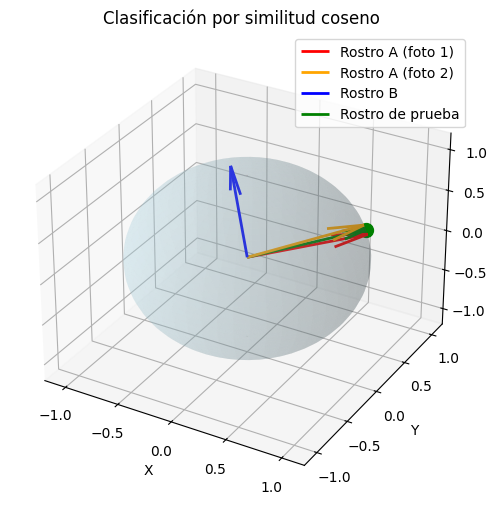

In [17]:
# Crear un nuevo vector de prueba (rostro desconocido)
v_prueba = np.array([0.75, 0.55, 0.25])
v_prueba_norm, _ = normalizar(v_prueba)

# Comparar con los vectores existentes
cos_sim_prueba_v1 = np.dot(v_prueba_norm, v1_norm)
cos_sim_prueba_v2 = np.dot(v_prueba_norm, v2_norm)
cos_sim_prueba_v3 = np.dot(v_prueba_norm, v3_norm)

print("Rostro de prueba comparado con:")
print(f"- Rostro A (foto 1): similitud = {cos_sim_prueba_v1:.4f}")
print(f"- Rostro A (foto 2): similitud = {cos_sim_prueba_v2:.4f}")
print(f"- Rostro B: similitud = {cos_sim_prueba_v3:.4f}")

# Determinar la clase más similar
similitudes = {
    'Rostro A (foto 1)': cos_sim_prueba_v1,
    'Rostro A (foto 2)': cos_sim_prueba_v2,
    'Rostro B': cos_sim_prueba_v3
}

mejor_clase = max(similitudes, key=similitudes.get)
print(f"\nEl rostro de prueba se parece más a: {mejor_clase}")

# Visualizar
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Dibujar esfera
ax.plot_surface(x_esfera, y_esfera, z_esfera, color='lightblue', alpha=0.2, edgecolor='none')

# Dibujar vectores existentes
ax.quiver(0, 0, 0, v1_norm[0], v1_norm[1], v1_norm[2], color='red', linewidth=2, label='Rostro A (foto 1)')
ax.quiver(0, 0, 0, v2_norm[0], v2_norm[1], v2_norm[2], color='orange', linewidth=2, label='Rostro A (foto 2)')
ax.quiver(0, 0, 0, v3_norm[0], v3_norm[1], v3_norm[2], color='blue', linewidth=2, label='Rostro B')

# Dibujar vector de prueba
ax.quiver(0, 0, 0, v_prueba_norm[0], v_prueba_norm[1], v_prueba_norm[2],
          color='green', linewidth=2, arrow_length_ratio=0.2, label='Rostro de prueba')

ax.scatter(v_prueba_norm[0], v_prueba_norm[1], v_prueba_norm[2], color='green', s=100)

ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Clasificación por similitud coseno')
ax.legend()

plt.show()

Explicación:

El rostro de prueba se compara con todos los rostros conocidos

Se selecciona el que tiene mayor similitud coseno

Esto es exactamente cómo funciona la clasificación en ArcFace

📌 Nota
Este nivel demuestra:

Normalización: elimina dependencia de magnitud (iluminación)

Similitud coseno: mide similitud por ángulo, no por distancia

Clasificación: el rostro de prueba se asigna a la clase más cercana en la esfera

# Nivel 2: Implementación simplificada de Eigenfaces -> NIVEL 2.1: Eigenfaces con imágenes reales


Objetivo
Implementar PCA completo con un dataset pequeño de imágenes reales, visualizar las Eigenfaces y clasificar rostros.

Matemática que aprenderás

* Representación de imágenes como vectores

* PCA completo (centrado, covarianza, autovalores, proyección)

* Distancia euclidiana para clasificación

* Visualización de Eigenfaces como imágenes

In [ ]:
## Paso 1: Importar librerías y preparar el dataset


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Cargar el dataset Olivetti Faces
# Contiene 400 imágenes de 40 personas (10 fotos por persona)
# Cada imagen es 64x64 píxeles = 4096 dimensiones
print("Cargando dataset Olivetti Faces...")
dataset = fetch_olivetti_faces(shuffle=True, random_state=42)

# Datos: 400 imágenes, cada una de 4096 píxeles
X = dataset.data  # Matriz de 400 x 4096
y = dataset.target  # Etiquetas (0 a 39, cada persona)

# Mostrar información
print(f"\nForma de la matriz de datos: {X.shape}")
print(f"Número de personas: {len(np.unique(y))}")
print(f"Imágenes por persona: {np.bincount(y)[0]}")
print(f"Dimensión original de cada imagen: 64x64 = 4096 píxeles")

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nEntrenamiento: {X_train.shape[0]} imágenes")
print(f"Prueba: {X_test.shape[0]} imágenes")

Cargando dataset Olivetti Faces...
downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data

Forma de la matriz de datos: (400, 4096)
Número de personas: 40
Imágenes por persona: 10
Dimensión original de cada imagen: 64x64 = 4096 píxeles

Entrenamiento: 280 imágenes
Prueba: 120 imágenes


Explicación:

Usamos el dataset Olivetti Faces (400 imágenes, 40 personas)

Cada imagen tiene 4096 píxeles → espacio de 4096 dimensiones

El objetivo es reducir esto a unas pocas dimensiones

## Paso 2: Visualizar algunas imágenes originales


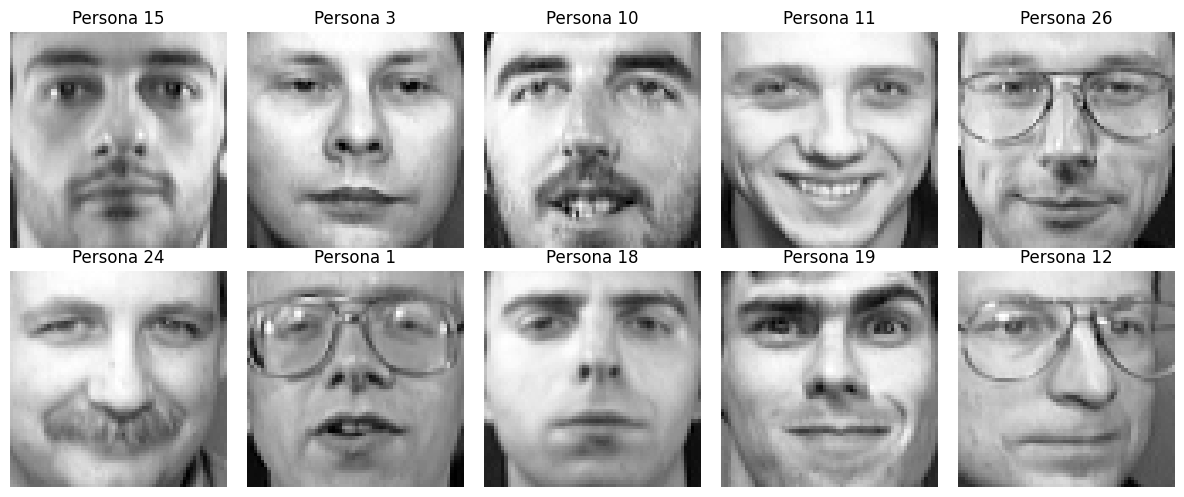

In [19]:
# Función para mostrar imágenes
def mostrar_imagenes(imagenes, titulos, filas=2, columnas=5):
    fig, axes = plt.subplots(filas, columnas, figsize=(12, 5))
    for i, ax in enumerate(axes.flat):
        if i < len(imagenes):
            ax.imshow(imagenes[i].reshape(64, 64), cmap='gray')
            ax.set_title(titulos[i])
            ax.axis('off')
    plt.tight_layout()
    plt.show()

# Mostrar primeras 10 imágenes de entrenamiento
primeras_imagenes = X_train[:10]
titulos = [f"Persona {y_train[i]}" for i in range(10)]
mostrar_imagenes(primeras_imagenes, titulos)

Explicación:

Cada imagen es un rostro en escala de grises

Cada persona tiene múltiples imágenes con variaciones de expresión y ángulo

Queremos encontrar patrones comunes entre rostros de la misma persona

## Paso 3: Calcular la cara promedio


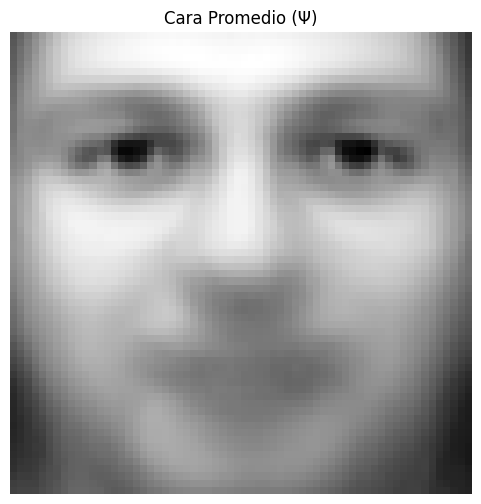

La cara promedio representa el rostro 'típico' del dataset
Eliminar esta cara nos permite enfocarnos en las diferencias entre personas


In [20]:
# Calcular la cara promedio (Ψ)
cara_promedio = np.mean(X_train, axis=0)

# Visualizar la cara promedio
plt.figure(figsize=(6, 6))
plt.imshow(cara_promedio.reshape(64, 64), cmap='gray')
plt.title('Cara Promedio (Ψ)')
plt.axis('off')
plt.show()

print("La cara promedio representa el rostro 'típico' del dataset")
print("Eliminar esta cara nos permite enfocarnos en las diferencias entre personas")

Explicación:

La cara promedio (Ψ) es el rostro que comparten todos los individuos

Restarla elimina la información común

Lo que queda (Φ) son los rasgos distintivos

##Paso 4: Centrar los datos (restar la cara promedio)


Datos centrados (Φ) calculados
Forma: (280, 4096)

La primera imagen centrada:


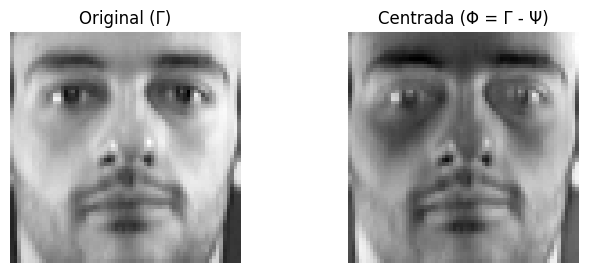

In [21]:
# Centrar los datos: Φ = Γ - Ψ
X_centrado = X_train - cara_promedio

print("Datos centrados (Φ) calculados")
print(f"Forma: {X_centrado.shape}")
print("\nLa primera imagen centrada:")
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(X_train[0].reshape(64, 64), cmap='gray')
plt.title('Original (Γ)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(X_centrado[0].reshape(64, 64), cmap='gray')
plt.title('Centrada (Φ = Γ - Ψ)')
plt.axis('off')
plt.show()

Explicación:

La imagen centrada resalta los rasgos únicos

Las zonas oscuras indican diferencias con el promedio

Es más fácil ver qué hace único a cada rostro

##Paso 5: Calcular la matriz de covarianza (versión eficiente)


In [22]:
# En lugar de calcular C = X_centrado.T @ X_centrado (4096x4096)
# Usamos el "truco" de Turk y Pentland: L = X_centrado @ X_centrado.T (280x280)

print("Calculando la matriz de covarianza eficiente...")
L = X_centrado @ X_centrado.T
print(f"Matriz L (280x280) en lugar de 4096x4096")

# Calcular autovalores y autovectores de L
autovalores_L, autovectores_L = np.linalg.eig(L)

# Ordenar de mayor a menor
idx = autovalores_L.argsort()[::-1]
autovalores_L = autovalores_L[idx]
autovectores_L = autovectores_L[:, idx]

# Recuperar las Eigenfaces (autovectores del espacio original)
# u_i = X_centrado.T @ v_i
k = 50  # Número de Eigenfaces a calcular
Vk = autovectores_L[:, :k]
eigenfaces = X_centrado.T @ Vk

# Normalizar Eigenfaces
for i in range(k):
    eigenfaces[:, i] = eigenfaces[:, i] / np.linalg.norm(eigenfaces[:, i])

print(f"\nCalculadas {k} Eigenfaces")
print(f"Cada Eigenface tiene {eigenfaces.shape[0]} dimensiones")

Calculando la matriz de covarianza eficiente...
Matriz L (280x280) en lugar de 4096x4096

Calculadas 50 Eigenfaces
Cada Eigenface tiene 4096 dimensiones


Explicación:

La matriz de covarianza original sería 4096×4096 (16 millones de elementos)

Usamos el "truco" de Turk y Pentland: L = X Xᵀ (280×280)

Las Eigenfaces se recuperan con u_i = Xᵀ v_i

##Paso 6: Visualizar las Eigenfaces


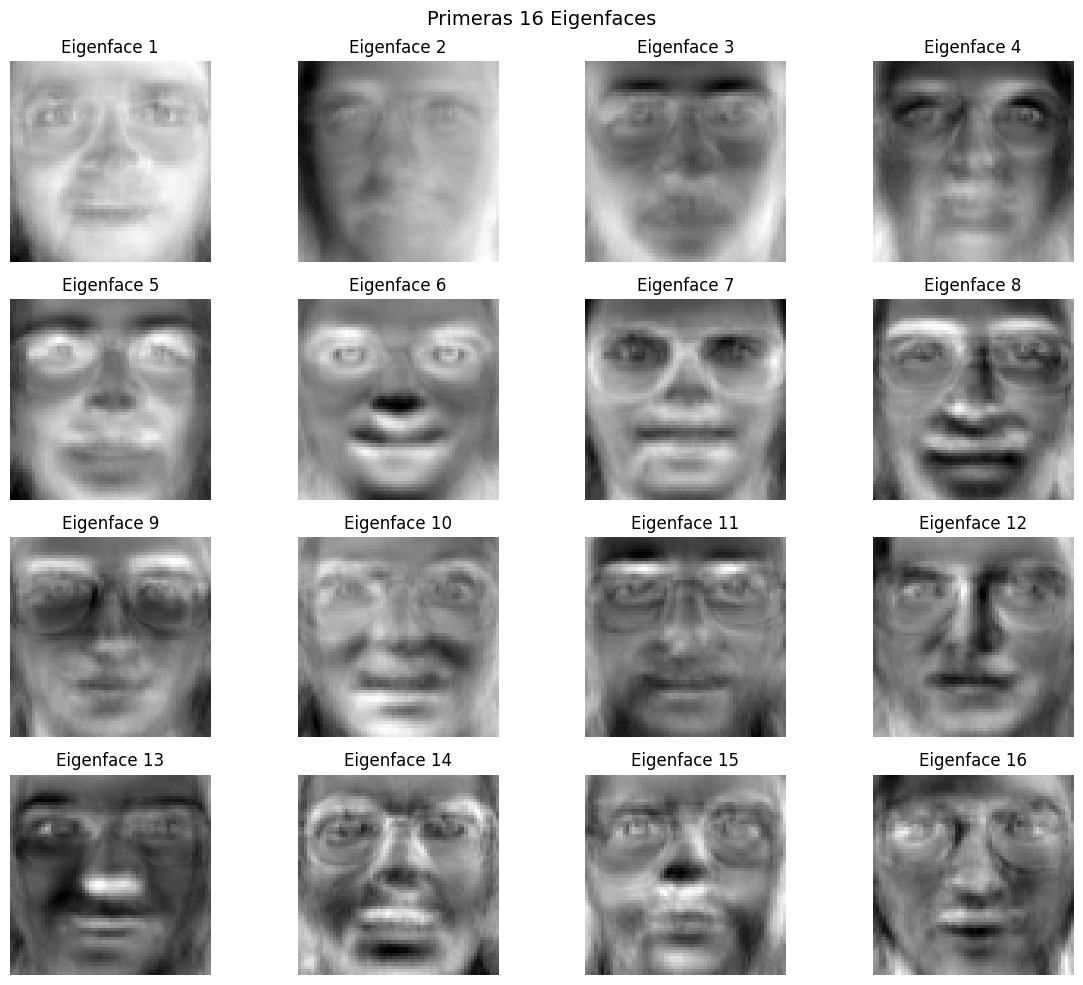

Interpretación:
- Cada Eigenface es un 'rasgo' facial abstracto
- Eigenface 1: variación de iluminación general
- Eigenface 2: diferencia entre rostros alargados vs redondos
- Eigenfaces posteriores: detalles más finos (ojos, nariz, etc.)


In [23]:
# Mostrar las primeras 16 Eigenfaces
fig, axes = plt.subplots(4, 4, figsize=(12, 10))
for i, ax in enumerate(axes.flat):
    if i < 16:
        eigenface = eigenfaces[:, i].reshape(64, 64)
        ax.imshow(eigenface, cmap='gray')
        ax.set_title(f'Eigenface {i+1}')
        ax.axis('off')
plt.suptitle('Primeras 16 Eigenfaces', fontsize=14)
plt.tight_layout()
plt.show()

print("Interpretación:")
print("- Cada Eigenface es un 'rasgo' facial abstracto")
print("- Eigenface 1: variación de iluminación general")
print("- Eigenface 2: diferencia entre rostros alargados vs redondos")
print("- Eigenfaces posteriores: detalles más finos (ojos, nariz, etc.)")

Explicación:

Las primeras Eigenfaces capturan las variaciones más importantes

Cada Eigenface es como un "ingrediente" para construir cualquier rostro

Combinando Eigenfaces podemos reconstruir cualquier rostro

## Paso 7: Proyectar rostros al espacio de Eigenfaces


In [24]:
def proyectar(imagen, eigenfaces):
    """Proyecta una imagen al espacio de Eigenfaces"""
    # Centrar la imagen
    imagen_centrada = imagen - cara_promedio
    # Proyectar: pesos = uᵀ · Φ
    pesos = imagen_centrada @ eigenfaces
    return pesos

# Proyectar todas las imágenes de entrenamiento
print("Proyectando imágenes al espacio de Eigenfaces...")
pesos_train = np.array([proyectar(img, eigenfaces) for img in X_train])
print(f"Pesos resultantes: {pesos_train.shape}")
print("Cada imagen ahora se representa con solo 50 números")

Proyectando imágenes al espacio de Eigenfaces...
Pesos resultantes: (280, 50)
Cada imagen ahora se representa con solo 50 números


Explicación:

Cada imagen de 4096 píxeles se reduce a 50 pesos

Estos pesos son la "receta" para reconstruir el rostro

La clasificación se hace en este espacio de 50 dimensiones

##Paso 8: Clasificar usando distancia euclidiana


In [25]:
def clasificar(imagen_test, pesos_train, y_train, eigenfaces):
    """Clasifica una imagen usando distancia euclidiana"""
    # Proyectar la imagen de prueba
    pesos_test = proyectar(imagen_test, eigenfaces)

    # Calcular distancia a todas las imágenes de entrenamiento
    distancias = np.linalg.norm(pesos_train - pesos_test, axis=1)

    # Encontrar la más cercana
    idx_min = np.argmin(distancias)
    return y_train[idx_min], distancias[idx_min]

# Probar con algunas imágenes de prueba
print("Clasificando imágenes de prueba...")
aciertos = 0
resultados = []

for i in range(min(20, len(X_test))):
    img_test = X_test[i]
    verdadero = y_test[i]
    predicho, distancia = clasificar(img_test, pesos_train, y_train, eigenfaces)
    aciertos += (predicho == verdadero)
    resultados.append((verdadero, predicho, distancia))
    print(f"  Imagen {i+1}: Verdadero={verdadero}, Predicho={predicho}, Distancia={distancia:.2f}")

print(f"\nPrecisión en 20 muestras: {aciertos/20*100:.1f}%")

Clasificando imágenes de prueba...
  Imagen 1: Verdadero=30, Predicho=30, Distancia=1.11
  Imagen 2: Verdadero=18, Predicho=18, Distancia=2.58
  Imagen 3: Verdadero=16, Predicho=16, Distancia=4.07
  Imagen 4: Verdadero=9, Predicho=9, Distancia=4.64
  Imagen 5: Verdadero=17, Predicho=17, Distancia=3.37
  Imagen 6: Verdadero=24, Predicho=24, Distancia=1.44
  Imagen 7: Verdadero=17, Predicho=17, Distancia=3.72
  Imagen 8: Verdadero=37, Predicho=37, Distancia=3.62
  Imagen 9: Verdadero=36, Predicho=36, Distancia=1.53
  Imagen 10: Verdadero=37, Predicho=37, Distancia=2.95
  Imagen 11: Verdadero=0, Predicho=0, Distancia=6.62
  Imagen 12: Verdadero=35, Predicho=35, Distancia=5.41
  Imagen 13: Verdadero=36, Predicho=36, Distancia=2.53
  Imagen 14: Verdadero=25, Predicho=25, Distancia=5.86
  Imagen 15: Verdadero=38, Predicho=38, Distancia=1.52
  Imagen 16: Verdadero=22, Predicho=22, Distancia=1.66
  Imagen 17: Verdadero=26, Predicho=26, Distancia=3.19
  Imagen 18: Verdadero=14, Predicho=14, Dis

Explicación:

La clasificación se basa en la distancia euclidiana en el espacio reducido

Menor distancia = mayor similitud

El rostro se asigna a la persona con la imagen más cercana

## Paso 9: Visualizar resultados de clasificación



Ejemplos de clasificación:


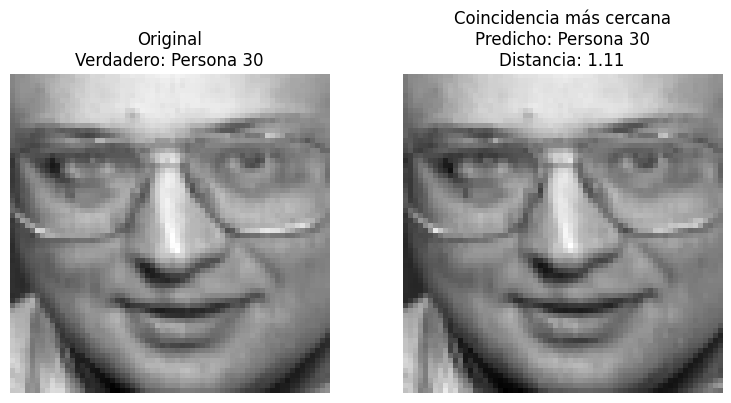

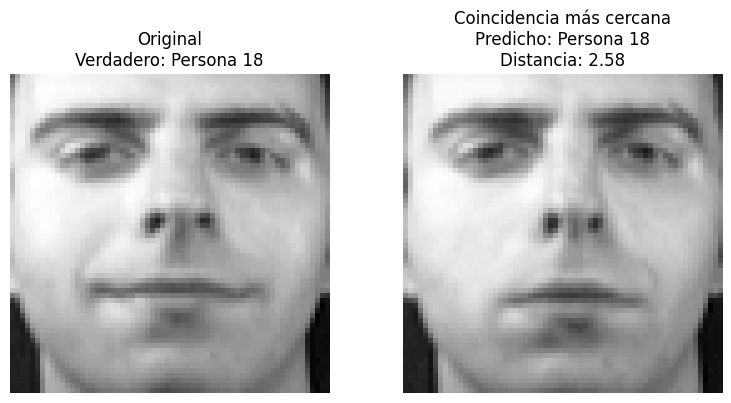

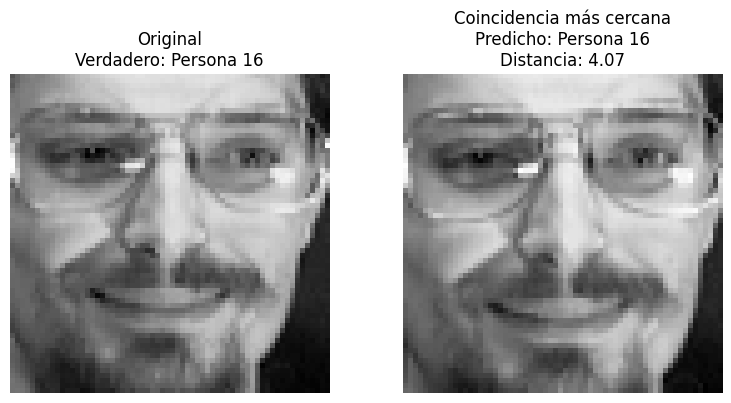

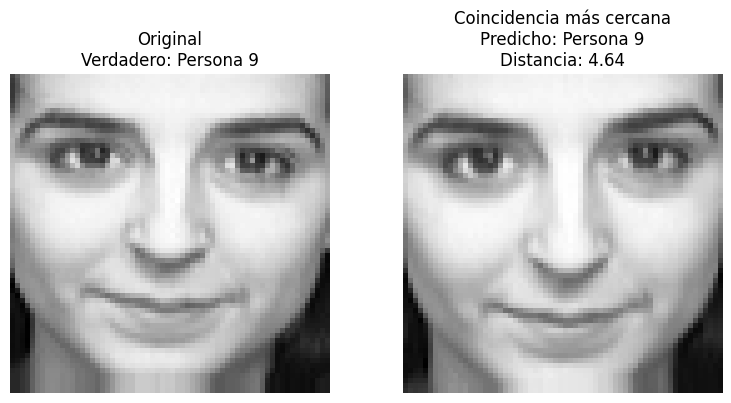

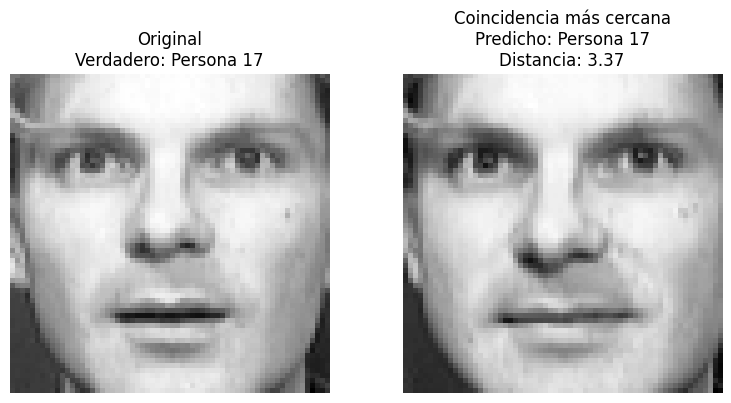

In [26]:
def mostrar_clasificacion(imagen, verdadero, predicho, distancia, eigenfaces):
    """Muestra una imagen con su clasificación"""
    pesos = proyectar(imagen, eigenfaces)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(imagen.reshape(64, 64), cmap='gray')
    plt.title(f'Original\nVerdadero: Persona {verdadero}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    # Encontrar la imagen más cercana en entrenamiento
    distancias = np.linalg.norm(pesos_train - pesos, axis=1)
    idx_min = np.argmin(distancias)
    imagen_cercana = X_train[idx_min]
    plt.imshow(imagen_cercana.reshape(64, 64), cmap='gray')
    plt.title(f'Coincidencia más cercana\nPredicho: Persona {predicho}\nDistancia: {distancia:.2f}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Mostrar algunos ejemplos
print("\nEjemplos de clasificación:")
for i in range(5):
    img = X_test[i]
    verdadero = y_test[i]
    predicho, distancia = clasificar(img, pesos_train, y_train, eigenfaces)
    mostrar_clasificacion(img, verdadero, predicho, distancia, eigenfaces)

Explicación:

A la izquierda: imagen original (persona verdadera)

A la derecha: imagen más cercana en el espacio de Eigenfaces

Si coinciden, la clasificación es correcta

## Paso 10: Reconstrucción de imágenes


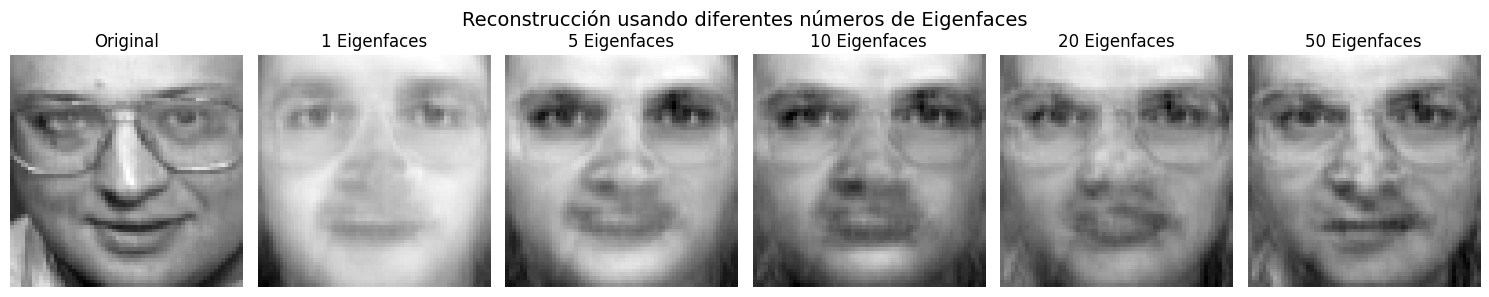

In [27]:
def reconstruir(pesos, eigenfaces, cara_promedio):
    """Reconstruye una imagen desde sus pesos"""
    return cara_promedio + pesos @ eigenfaces.T

# Tomar una imagen de prueba
imagen_original = X_test[0]
pesos = proyectar(imagen_original, eigenfaces)

# Reconstruir usando diferentes números de Eigenfaces
num_componentes = [1, 5, 10, 20, 50]

fig, axes = plt.subplots(1, len(num_componentes) + 1, figsize=(15, 3))

# Original
axes[0].imshow(imagen_original.reshape(64, 64), cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# Reconstrucciones
for i, k in enumerate(num_componentes):
    # Usar solo las primeras k Eigenfaces
    eigenfaces_k = eigenfaces[:, :k]
    pesos_k = imagen_original @ eigenfaces_k
    reconstruida = cara_promedio + pesos_k @ eigenfaces_k.T

    axes[i+1].imshow(reconstruida.reshape(64, 64), cmap='gray')
    axes[i+1].set_title(f'{k} Eigenfaces')
    axes[i+1].axis('off')

plt.suptitle('Reconstrucción usando diferentes números de Eigenfaces', fontsize=14)
plt.tight_layout()
plt.show()

Explicación:

Con pocas Eigenfaces (1-5) se ve solo la silueta

Con más Eigenfaces (20-50) se recuperan los detalles

Esto muestra cómo PCA conserva la información más importante

Este notebook ahora tiene:

Nivel 1.1: PCA en 2D con datos sintéticos

Nivel 1.2: Similitud coseno en 3D

Nivel 2.1: Eigenfaces con imágenes reales (Olivetti Faces)

# Nivel 2: Implementación simplificada de Eigenfaces -> NIVEL 2.2: Comparación de distancias (euclidiana vs coseno)


Objetivo
Comparar la distancia euclidiana y la similitud coseno para clasificación facial, entendiendo cuándo cada métrica es más adecuada.

Matemática que aprenderás
* Distancia euclidiana

* Similitud coseno
* Efecto de la escala y la magnitud en ambas métricas

* Normalización de vectores



##Paso 1: Importar librerías y preparar datos


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset Olivetti Faces
print("Cargando dataset Olivetti Faces...")
dataset = fetch_olivetti_faces(shuffle=True, random_state=42)
X = dataset.data  # 400 imágenes x 4096 píxeles
y = dataset.target  # 40 personas (0-39)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Datos de entrenamiento: {X_train.shape[0]} imágenes")
print(f"Datos de prueba: {X_test.shape[0]} imágenes")

Cargando dataset Olivetti Faces...
Datos de entrenamiento: 280 imágenes
Datos de prueba: 120 imágenes


## Paso 2: Reducir dimensionalidad con PCA (para visualización)


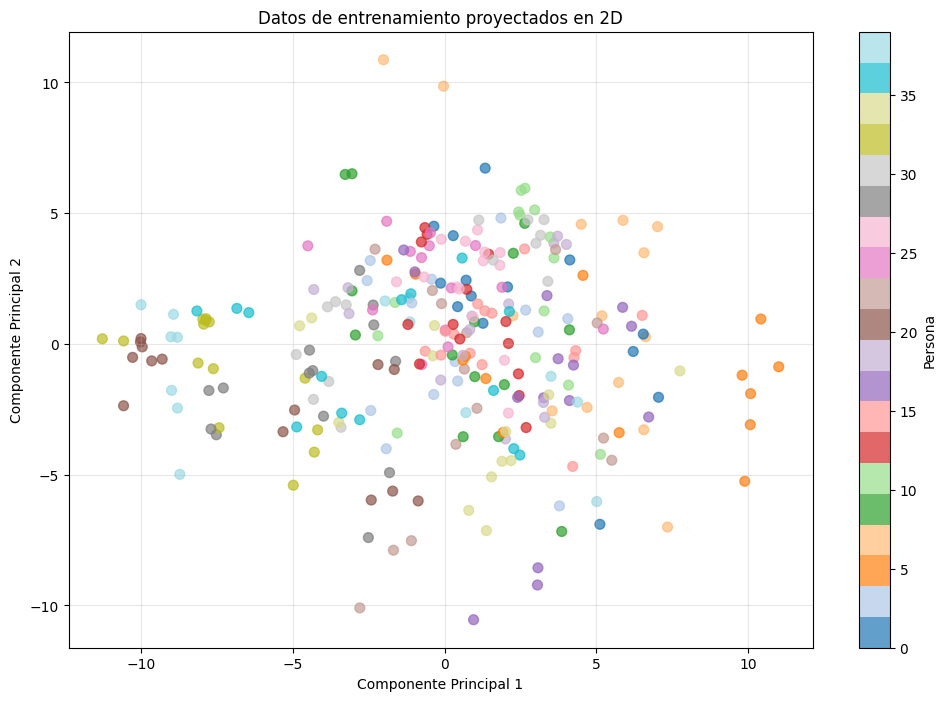

En 2D podemos visualizar las distancias entre rostros


In [29]:
from sklearn.decomposition import PCA

# Reducir a 2D para visualización
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)

# Visualizar los datos en 2D
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                      c=y_train, cmap='tab20', alpha=0.7, s=50)
plt.colorbar(scatter, label='Persona')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Datos de entrenamiento proyectados en 2D')
plt.grid(True, alpha=0.3)
plt.show()

print("En 2D podemos visualizar las distancias entre rostros")

Lo que ves en este código:
Qué hace: Reduce 280 rostros (cada uno con 4096 píxeles) a solo 2 números por rostro, para poder dibujarlos en un gráfico.

Qué ves en el gráfico:

Cada punto = un rostro

Color diferente = persona diferente

Puntos del mismo color = misma persona

Qué significa:

Si los puntos del mismo color están juntos → el sistema puede reconocer a esa persona

Si están mezclados con otros colores → el sistema se confundirá

Por qué es útil: Te permite ver visualmente si tu modelo de reconocimiento funciona antes de hacer cálculos complejos.

## Paso 3: Definir funciones de distancia y similitud


In [30]:
def distancia_euclidiana(a, b):
    """Calcula la distancia euclidiana entre dos vectores"""
    return np.sqrt(np.sum((a - b) ** 2))

def similitud_coseno(a, b):
    """Calcula la similitud coseno entre dos vectores"""
    # Producto escalar / (normas)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def distancia_coseno(a, b):
    """Distancia basada en similitud coseno"""
    return 1 - similitud_coseno(a, b)

# Probar con un ejemplo simple
v1 = np.array([1, 0])
v2 = np.array([0.8, 0.6])
v3 = np.array([-1, 0])

print("Ejemplo simple en 2D:")
print(f"v1 = {v1}")
print(f"v2 = {v2}")
print(f"v3 = {v3}")
print(f"\nDistancia euclidiana v1-v2: {distancia_euclidiana(v1, v2):.3f}")
print(f"Distancia coseno v1-v2: {distancia_coseno(v1, v2):.3f}")
print(f"\nDistancia euclidiana v1-v3: {distancia_euclidiana(v1, v3):.3f}")
print(f"Distancia coseno v1-v3: {distancia_coseno(v1, v3):.3f}")

Ejemplo simple en 2D:
v1 = [1 0]
v2 = [0.8 0.6]
v3 = [-1  0]

Distancia euclidiana v1-v2: 0.632
Distancia coseno v1-v2: 0.200

Distancia euclidiana v1-v3: 2.000
Distancia coseno v1-v3: 2.000


Lo que ves en este ejemplo:
Vectores:

v1 = [1, 0] → apunta a la derecha

v2 = [0.8, 0.6] → apunta a la derecha y arriba (ángulo 37°)

v3 = [-1, 0] → apunta a la izquierda (ángulo 180°)

Resultados:

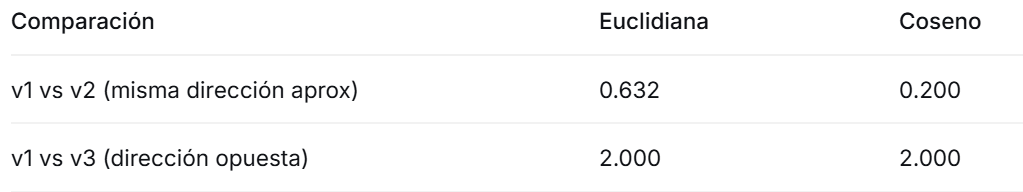

Interpretación:

Euclidiana: v1 vs v2 da 0.632 (distancia pequeña porque están cerca)

Coseno: v1 vs v2 da 0.200 (distancia pequeña porque el ángulo es pequeño)

Ambas métricas dan 2.000 en v1 vs v3 porque están muy separados

Conclusión: En este caso ambas métricas funcionan igual porque los vectores tienen magnitud similar. La diferencia aparece cuando un vector es más grande que otro (cambia iluminación).

##Paso 4: Efecto de la escala en ambas métricas


In [31]:
# Crear vectores con diferentes escalas
v_base = np.array([0.5, 0.5, 0.5])  # Vector base
v_escalado = v_base * 10  # Misma dirección, 10 veces más grande
v_diferente = np.array([0.6, 0.4, 0.5])  # Dirección ligeramente diferente

print("Efecto de la escala en las métricas:")
print(f"v_base = {v_base}")
print(f"v_escalado = {v_escalado}")
print(f"v_diferente = {v_diferente}")

print(f"\nDistancia euclidiana (base vs escalado): {distancia_euclidiana(v_base, v_escalado):.3f}")
print(f"Similitud coseno (base vs escalado): {similitud_coseno(v_base, v_escalado):.3f}")

print(f"\nDistancia euclidiana (base vs diferente): {distancia_euclidiana(v_base, v_diferente):.3f}")
print(f"Similitud coseno (base vs diferente): {similitud_coseno(v_base, v_diferente):.3f}")

print("\nInterpretación:")
print("- Distancia euclidiana: sensible a la escala (magnitud)")
print("- Similitud coseno: invariante a la escala (solo importa dirección)")
print("- En reconocimiento facial, la iluminación afecta la magnitud, no la dirección")

Efecto de la escala en las métricas:
v_base = [0.5 0.5 0.5]
v_escalado = [5. 5. 5.]
v_diferente = [0.6 0.4 0.5]

Distancia euclidiana (base vs escalado): 7.794
Similitud coseno (base vs escalado): 1.000

Distancia euclidiana (base vs diferente): 0.141
Similitud coseno (base vs diferente): 0.987

Interpretación:
- Distancia euclidiana: sensible a la escala (magnitud)
- Similitud coseno: invariante a la escala (solo importa dirección)
- En reconocimiento facial, la iluminación afecta la magnitud, no la dirección


## Paso 5: Comparar ambas métricas en rostros reales


Comparación en rostros reales:

Misma persona:
  Distancia euclidiana: 10.41
  Distancia coseno: 0.0337

Persona diferente:
  Distancia euclidiana: 11.04
  Distancia coseno: 0.0385


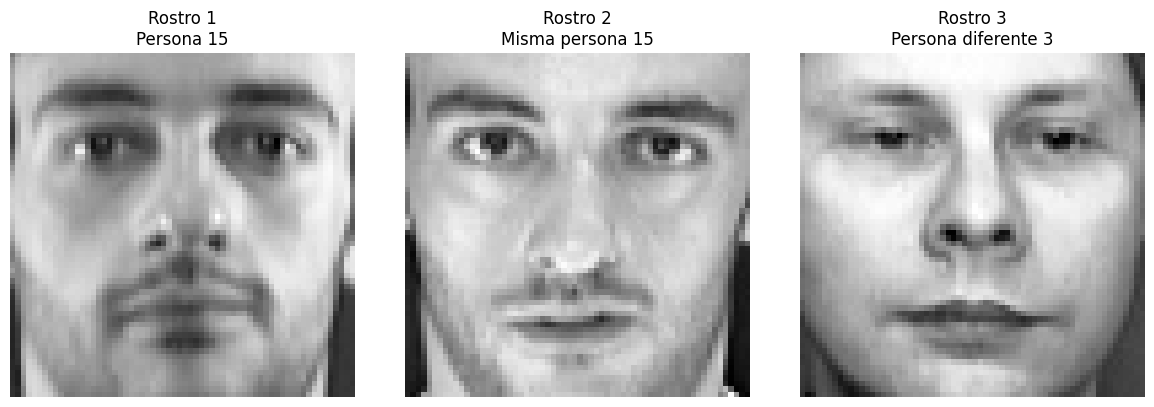

In [32]:
# Tomar imágenes de ejemplo
# Rostros de la misma persona (misma etiqueta)
idx_misma_persona = np.where(y_train == y_train[0])[0][:2]
rostro1 = X_train[idx_misma_persona[0]]
rostro2 = X_train[idx_misma_persona[1]]

# Rostro de persona diferente
idx_persona_distinta = np.where(y_train != y_train[0])[0][0]
rostro3 = X_train[idx_persona_distinta]

# Calcular distancias
dist_eucl_misma = distancia_euclidiana(rostro1, rostro2)
dist_cos_misma = distancia_coseno(rostro1, rostro2)

dist_eucl_distinta = distancia_euclidiana(rostro1, rostro3)
dist_cos_distinta = distancia_coseno(rostro1, rostro3)

print("Comparación en rostros reales:")
print(f"\nMisma persona:")
print(f"  Distancia euclidiana: {dist_eucl_misma:.2f}")
print(f"  Distancia coseno: {dist_cos_misma:.4f}")

print(f"\nPersona diferente:")
print(f"  Distancia euclidiana: {dist_eucl_distinta:.2f}")
print(f"  Distancia coseno: {dist_cos_distinta:.4f}")

# Visualizar los rostros
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(rostro1.reshape(64, 64), cmap='gray')
axes[0].set_title(f'Rostro 1\nPersona {y_train[0]}')
axes[0].axis('off')

axes[1].imshow(rostro2.reshape(64, 64), cmap='gray')
axes[1].set_title(f'Rostro 2\nMisma persona {y_train[0]}')
axes[1].axis('off')

axes[2].imshow(rostro3.reshape(64, 64), cmap='gray')
axes[2].set_title(f'Rostro 3\nPersona diferente {y_train[idx_persona_distinta]}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Paso 6: Simular el efecto de la iluminación en ambas métricas


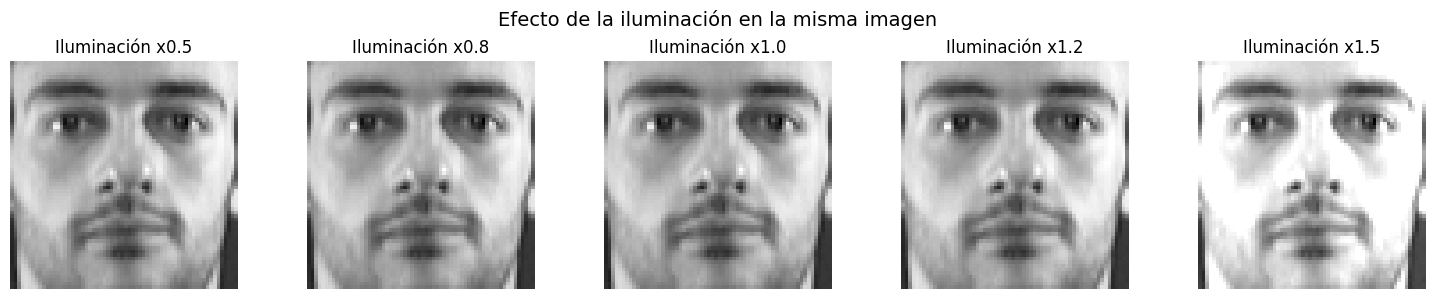

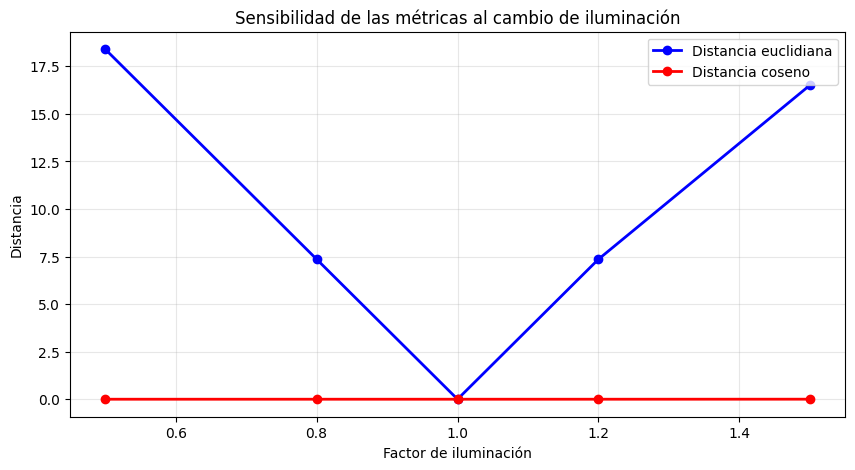


Interpretación:
- La distancia euclidiana cambia drásticamente con la iluminación
- La distancia coseno permanece casi constante
- Esto explica por qué ArcFace usa similitud coseno: es invariante a la iluminación


In [33]:
# Crear una imagen base y modificar su brillo (escala)
imagen_base = X_train[0]
# Simular diferentes niveles de iluminación (escalar la intensidad)
iluminacion = [0.5, 0.8, 1.0, 1.2, 1.5]

distancias_eucl = []
distancias_cos = []

for factor in iluminacion:
    # Escalar la imagen (simular cambio de iluminación)
    imagen_iluminada = imagen_base * factor
    # Limitar valores al rango [0, 1] (normalizado)
    imagen_iluminada = np.clip(imagen_iluminada, 0, 1)

    dist_eucl = distancia_euclidiana(imagen_base, imagen_iluminada)
    dist_cos = distancia_coseno(imagen_base, imagen_iluminada)

    distancias_eucl.append(dist_eucl)
    distancias_cos.append(dist_cos)

# Visualizar
fig, axes = plt.subplots(1, len(iluminacion), figsize=(15, 3))
for i, (factor, img) in enumerate(zip(iluminacion, distancias_eucl)):
    img_vis = imagen_base * factor
    img_vis = np.clip(img_vis, 0, 1)
    axes[i].imshow(img_vis.reshape(64, 64), cmap='gray')
    axes[i].set_title(f'Iluminación x{factor}')
    axes[i].axis('off')
plt.suptitle('Efecto de la iluminación en la misma imagen', fontsize=14)
plt.tight_layout()
plt.show()

# Graficar cómo cambian las distancias
plt.figure(figsize=(10, 5))
plt.plot(iluminacion, distancias_eucl, 'bo-', label='Distancia euclidiana', linewidth=2)
plt.plot(iluminacion, distancias_cos, 'ro-', label='Distancia coseno', linewidth=2)
plt.xlabel('Factor de iluminación')
plt.ylabel('Distancia')
plt.title('Sensibilidad de las métricas al cambio de iluminación')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nInterpretación:")
print("- La distancia euclidiana cambia drásticamente con la iluminación")
print("- La distancia coseno permanece casi constante")
print("- Esto explica por qué ArcFace usa similitud coseno: es invariante a la iluminación")

## Paso 7: Normalizar vectores y comparar

In [34]:
def normalizar(v):
    """Normaliza un vector a norma unitaria"""
    return v / np.linalg.norm(v)

# Tomar dos rostros de la misma persona con diferente iluminación
rostro_original = X_train[0]
rostro_oscuro = X_train[0] * 0.5
rostro_claro = X_train[0] * 1.5

# Limitar valores
rostro_oscuro = np.clip(rostro_oscuro, 0, 1)
rostro_claro = np.clip(rostro_claro, 0, 1)

# Normalizar
rostro_norm = normalizar(rostro_original)
rostro_oscuro_norm = normalizar(rostro_oscuro)
rostro_claro_norm = normalizar(rostro_claro)

print("Efecto de la normalización:")
print(f"\nSin normalizar:")
print(f"  Original vs Oscuro (euclidiana): {distancia_euclidiana(rostro_original, rostro_oscuro):.3f}")
print(f"  Original vs Oscuro (coseno): {distancia_coseno(rostro_original, rostro_oscuro):.3f}")

print(f"\nDespués de normalizar:")
print(f"  Original vs Oscuro (euclidiana): {distancia_euclidiana(rostro_norm, rostro_oscuro_norm):.3f}")
print(f"  Original vs Oscuro (coseno): {distancia_coseno(rostro_norm, rostro_oscuro_norm):.3f}")

Efecto de la normalización:

Sin normalizar:
  Original vs Oscuro (euclidiana): 18.400
  Original vs Oscuro (coseno): -0.000

Después de normalizar:
  Original vs Oscuro (euclidiana): 0.000
  Original vs Oscuro (coseno): -0.000


## Paso 8: Clasificación con ambas métricas


In [35]:
# Reducir dimensionalidad con PCA a 50 componentes (más realista)
pca_50 = PCA(n_components=50)
X_train_pca = pca_50.fit_transform(X_train)
X_test_pca = pca_50.transform(X_test)

def clasificar_con_metrica(X_train, y_train, X_test, metrica):
    """Clasifica usando la métrica especificada"""
    predicciones = []
    for test_img in X_test:
        if metrica == 'euclidiana':
            distancias = [distancia_euclidiana(test_img, train_img) for train_img in X_train]
        elif metrica == 'coseno':
            distancias = [distancia_coseno(test_img, train_img) for train_img in X_train]

        idx_min = np.argmin(distancias)
        predicciones.append(y_train[idx_min])
    return np.array(predicciones)

# Clasificar con ambas métricas
print("Clasificando con ambas métricas...")
pred_eucl = clasificar_con_metrica(X_train_pca, y_train, X_test_pca[:50], 'euclidiana')
pred_cos = clasificar_con_metrica(X_train_pca, y_train, X_test_pca[:50], 'coseno')

# Calcular precisión
acc_eucl = np.mean(pred_eucl == y_test[:50]) * 100
acc_cos = np.mean(pred_cos == y_test[:50]) * 100

print(f"\nPrecisión con distancia euclidiana: {acc_eucl:.1f}%")
print(f"Precisión con similitud coseno: {acc_cos:.1f}%")

# Comparar dónde difieren
diferencias = np.where(pred_eucl != pred_cos)[0]
print(f"\nLas métricas difieren en {len(diferencias)} de 50 casos")

if len(diferencias) > 0:
    print("\nEjemplo de diferencia:")
    idx = diferencias[0]
    print(f"  Caso {idx}:")
    print(f"    Verdadero: {y_test[idx]}")
    print(f"    Euclidiana predijo: {pred_eucl[idx]}")
    print(f"    Coseno predijo: {pred_cos[idx]}")

Clasificando con ambas métricas...

Precisión con distancia euclidiana: 96.0%
Precisión con similitud coseno: 96.0%

Las métricas difieren en 2 de 50 casos

Ejemplo de diferencia:
  Caso 29:
    Verdadero: 22
    Euclidiana predijo: 8
    Coseno predijo: 22


## Paso 9: Visualización comparativa


In [36]:
# Tomar un caso donde las métricas difieren
if len(diferencias) > 0:
    idx_caso = diferencias[0]
    img_test = X_test_pca[idx_caso]

    # Calcular distancias a todas las imágenes de entrenamiento
    dist_eucl = [distancia_euclidiana(img_test, train_img) for train_img in X_train_pca]
    dist_cos = [distancia_coseno(img_test, train_img) for train_img in X_train_pca]

    # Encontrar los 5 más cercanos con cada métrica
    top5_eucl = np.argsort(dist_eucl)[:5]
    top5_cos = np.argsort(dist_cos)[:5]

    print(f"\nAnálisis del caso donde difieren:")
    print(f"Verdadero: Persona {y_test[idx_caso]}")

    print(f"\nTop 5 con distancia euclidiana:")
    for i, idx in enumerate(top5_eucl):
        print(f"  {i+1}. Persona {y_train[idx]} (dist: {dist_eucl[idx]:.3f})")

    print(f"\nTop 5 con similitud coseno:")
    for i, idx in enumerate(top5_cos):
        print(f"  {i+1}. Persona {y_train[idx]} (dist: {dist_cos[idx]:.3f})")


Análisis del caso donde difieren:
Verdadero: Persona 22

Top 5 con distancia euclidiana:
  1. Persona 8 (dist: 4.702)
  2. Persona 22 (dist: 5.036)
  3. Persona 22 (dist: 5.068)
  4. Persona 39 (dist: 5.279)
  5. Persona 22 (dist: 5.333)

Top 5 con similitud coseno:
  1. Persona 22 (dist: 0.184)
  2. Persona 8 (dist: 0.276)
  3. Persona 22 (dist: 0.282)
  4. Persona 39 (dist: 0.391)
  5. Persona 12 (dist: 0.410)


## Paso 10: Resumen y conclusiones


In [37]:
print("\n" + "="*50)
print("CONCLUSIONES: Distancia Euclidiana vs Similitud Coseno")
print("="*50)

print("""
1. DISTANCIA EUCLIDIANA:
   - Mide la distancia geométrica directa entre dos puntos
   - Sensible a la escala (magnitud de los vectores)
   - Afectada por cambios de iluminación y contraste
   - Útil cuando la magnitud es importante

2. SIMILITUD COSENO:
   - Mide el ángulo entre dos vectores
   - Invariante a la escala (solo importa la dirección)
   - Robusta ante cambios de iluminación
   - Ideal para comparar embeddings faciales

3. EN EL CONTEXTO DEL RECONOCIMIENTO FACIAL:
   - ArcFace utiliza similitud coseno normalizada en hiperesfera
   - La normalización elimina la dependencia de la iluminación
   - El margen angular mejora la separación entre clases
   - Esto explica por qué los métodos modernos superan a los clásicos
""")


CONCLUSIONES: Distancia Euclidiana vs Similitud Coseno

1. DISTANCIA EUCLIDIANA:
   - Mide la distancia geométrica directa entre dos puntos
   - Sensible a la escala (magnitud de los vectores)
   - Afectada por cambios de iluminación y contraste
   - Útil cuando la magnitud es importante

2. SIMILITUD COSENO:
   - Mide el ángulo entre dos vectores
   - Invariante a la escala (solo importa la dirección)
   - Robusta ante cambios de iluminación
   - Ideal para comparar embeddings faciales

3. EN EL CONTEXTO DEL RECONOCIMIENTO FACIAL:
   - ArcFace utiliza similitud coseno normalizada en hiperesfera
   - La normalización elimina la dependencia de la iluminación
   - El margen angular mejora la separación entre clases
   - Esto explica por qué los métodos modernos superan a los clásicos



# Nivel 3: Simulación de gradiente descendente -> NIVEL 3.1: Optimización de una función simple


Objetivo

Entender cómo el gradiente descendente permite encontrar el mínimo de una función, que es la base del entrenamiento de redes neuronales.

## Paso 1: Definir la función y su derivada


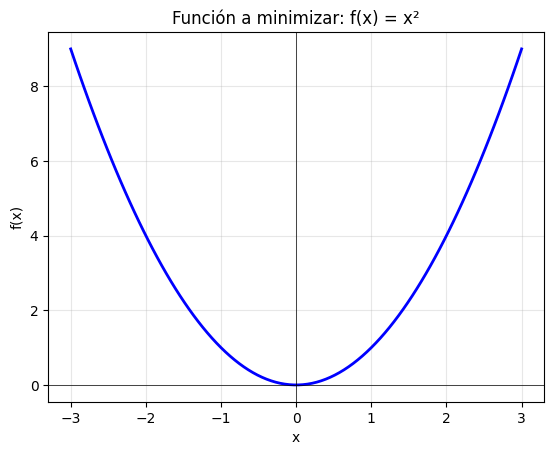

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Función cuadrática: f(x) = x²
def f(x):
    return x**2

# Derivada: f'(x) = 2x
def derivada(x):
    return 2*x

# Graficar
x = np.linspace(-3, 3, 100)
plt.plot(x, f(x), 'b-', linewidth=2)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Función a minimizar: f(x) = x²')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.show()

Explicación: Queremos encontrar x que haga f(x) mínima. El mínimo está en x=0.

##Paso 2: Gradiente descendente paso a paso


In [39]:
# Parámetros
x_actual = 2.5          # Punto de partida
tasa_aprendizaje = 0.2  # Tamaño de cada paso
iteraciones = 10

print("Paso a paso del gradiente descendente:")
print(f"x inicial = {x_actual:.4f}, f(x) = {f(x_actual):.4f}")

for i in range(iteraciones):
    grad = derivada(x_actual)              # Calcular pendiente
    x_actual = x_actual - tasa_aprendizaje * grad  # Dar el paso
    print(f"Paso {i+1}: x = {x_actual:.4f}, f(x) = {f(x_actual):.4f}")

Paso a paso del gradiente descendente:
x inicial = 2.5000, f(x) = 6.2500
Paso 1: x = 1.5000, f(x) = 2.2500
Paso 2: x = 0.9000, f(x) = 0.8100
Paso 3: x = 0.5400, f(x) = 0.2916
Paso 4: x = 0.3240, f(x) = 0.1050
Paso 5: x = 0.1944, f(x) = 0.0378
Paso 6: x = 0.1166, f(x) = 0.0136
Paso 7: x = 0.0700, f(x) = 0.0049
Paso 8: x = 0.0420, f(x) = 0.0018
Paso 9: x = 0.0252, f(x) = 0.0006
Paso 10: x = 0.0151, f(x) = 0.0002


Explicación: En cada paso, restamos el gradiente × tasa_aprendizaje. Así nos movemos hacia abajo.

## Paso 3: Visualizar la trayectoria


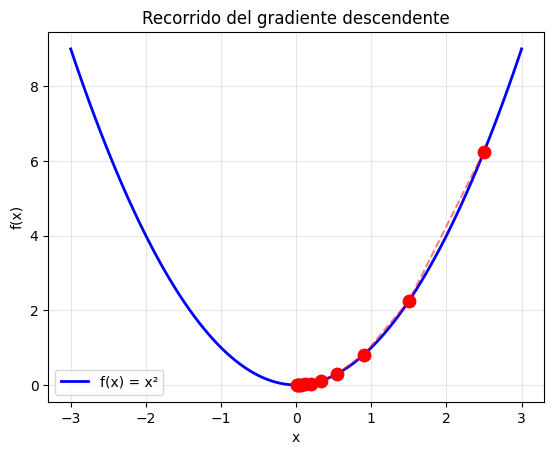

In [40]:
# Repetir guardando historial
x_actual = 2.5
historial_x = [x_actual]
historial_f = [f(x_actual)]

for _ in range(10):
    grad = derivada(x_actual)
    x_actual = x_actual - 0.2 * grad
    historial_x.append(x_actual)
    historial_f.append(f(x_actual))

# Graficar
x_grafico = np.linspace(-3, 3, 100)
plt.plot(x_grafico, f(x_grafico), 'b-', linewidth=2, label='f(x) = x²')
plt.scatter(historial_x, historial_f, color='red', s=80, zorder=5)
plt.plot(historial_x, historial_f, 'r--', alpha=0.5)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Recorrido del gradiente descendente')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Explicación: Los puntos rojos muestran el camino desde x=2.5 hasta cerca de x=0.



##Paso 4: Comparar diferentes tasas de aprendizaje


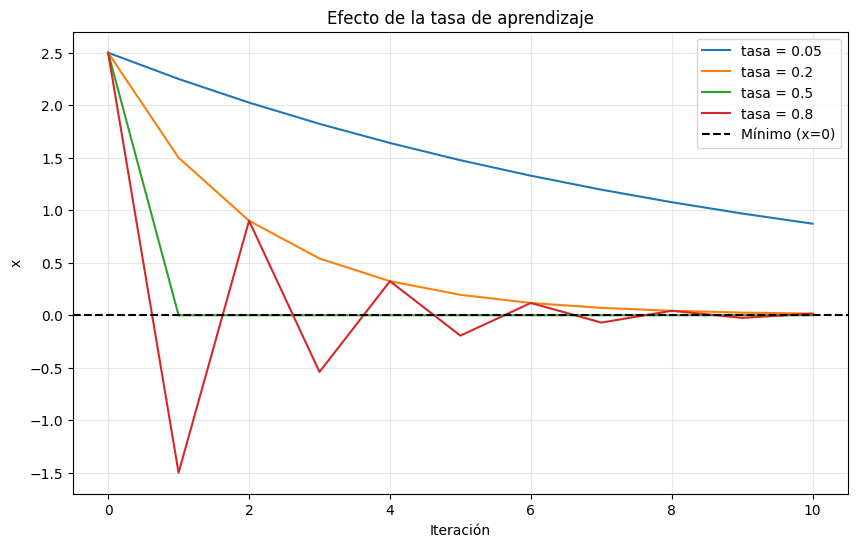

In [41]:
def gradiente_descendente(tasa, inicio=2.5, pasos=10):
    x = inicio
    historial = [x]
    for _ in range(pasos):
        x = x - tasa * derivada(x)
        historial.append(x)
    return historial

# Probar tasas
plt.figure(figsize=(10, 6))
for tasa in [0.05, 0.2, 0.5, 0.8]:
    hist = gradiente_descendente(tasa)
    plt.plot(hist, label=f'tasa = {tasa}')

plt.axhline(y=0, color='black', linestyle='--', label='Mínimo (x=0)')
plt.xlabel('Iteración')
plt.ylabel('x')
plt.title('Efecto de la tasa de aprendizaje')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Explicación:

tasa pequeña (0.05): avanza lento

tasa media (0.2): llega bien

tasa grande (0.8): oscila alrededor del mínimo

## Paso 5: Conectar con redes neuronales


In [42]:
print("\n" + "="*50)
print("CONEXIÓN CON RECONOCIMIENTO FACIAL")
print("="*50)

print("""
En ArcFace (red neuronal):

- x → pesos de la red (millones de números)
- f(x) → función de pérdida (qué tan mal clasifica)
- derivada → gradiente (calculado con retropropagación)
- tasa_aprendizaje → learning rate (ej. 0.001)

El proceso es el mismo pero en alta dimensión.
Cada iteración = una época de entrenamiento.
Al final, la red aprende a separar rostros.
""")


CONEXIÓN CON RECONOCIMIENTO FACIAL

En ArcFace (red neuronal):

- x → pesos de la red (millones de números)
- f(x) → función de pérdida (qué tan mal clasifica)
- derivada → gradiente (calculado con retropropagación)
- tasa_aprendizaje → learning rate (ej. 0.001)

El proceso es el mismo pero en alta dimensión.
Cada iteración = una época de entrenamiento.
Al final, la red aprende a separar rostros.



Explicación: Lo que viste en 1D aplica a millones de dimensiones. El gradiente indica la dirección para reducir el error.

# Nivel 3: Simulación de gradiente descendente -> NIVEL 3.2: Margen angular simplificado (ArcFace didáctico)

Objetivo

Entender cómo el margen angular en ArcFace separa mejor las clases.



## Paso 1: Crear datos de dos clases en el círculo unitario


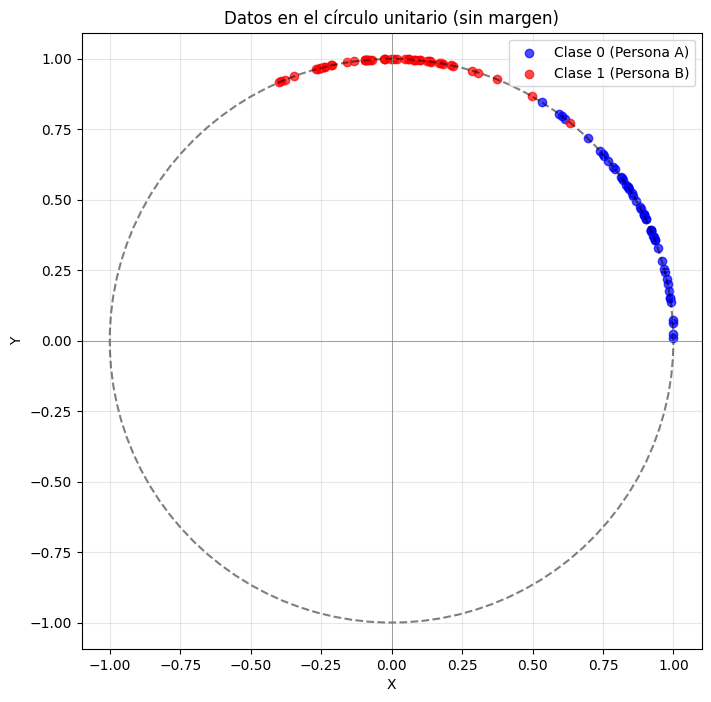

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Fijar semilla
np.random.seed(42)

# Clase 0: ángulos alrededor de 30° (misma persona)
angulos_clase0 = np.random.normal(30, 15, 50)

# Clase 1: ángulos alrededor de 90° (otra persona)
angulos_clase1 = np.random.normal(90, 15, 50)

# Convertir a coordenadas en el círculo unitario
x0 = np.cos(np.radians(angulos_clase0))
y0 = np.sin(np.radians(angulos_clase0))

x1 = np.cos(np.radians(angulos_clase1))
y1 = np.sin(np.radians(angulos_clase1))

# Visualizar
plt.figure(figsize=(8, 8))
plt.scatter(x0, y0, c='blue', alpha=0.7, label='Clase 0 (Persona A)')
plt.scatter(x1, y1, c='red', alpha=0.7, label='Clase 1 (Persona B)')

# Dibujar círculo unitario
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5)

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.axis('equal')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Datos en el círculo unitario (sin margen)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Explicación: Cada punto es un rostro. Queremos separar Clase 0 (azul) de Clase 1 (rojo). Están mezclados cerca de los límites.

##Paso 2: Definir función de pérdida sin margen


In [44]:
def loss_sin_margen(theta_clase0, theta_clase1, s=10):
    """Pérdida simplificada: separar clase0 de clase1"""
    # Ángulo medio de cada clase
    theta0_promedio = np.mean(theta_clase0)
    theta1_promedio = np.mean(theta_clase1)

    # Distancia angular entre centros
    distancia_angular = abs(theta0_promedio - theta1_promedio)

    # Pérdida = menor distancia angular = mayor error
    return 1 / (distancia_angular + 0.1)

Explicación: Si las clases están cerca, la pérdida es alta. Si están lejos, la pérdida es baja.



##Paso 3: Definir función con margen angular


In [45]:
def loss_con_margen(theta_clase0, theta_clase1, margen=20, s=10):
    """Pérdida con margen angular: fuerza separación extra"""
    theta0_promedio = np.mean(theta_clase0)
    theta1_promedio = np.mean(theta_clase1)

    # Distancia angular entre centros
    distancia_angular = abs(theta0_promedio - theta1_promedio)

    # Si la distancia es menor que el margen, aumentar pérdida
    if distancia_angular < margen:
        penalizacion = (margen - distancia_angular) / margen
        return 1 / (distancia_angular + 0.1) + penalizacion * 5
    else:
        return 1 / (distancia_angular + 0.1)

Explicación: Si las clases están a menos de 20°, la pérdida aumenta. Esto fuerza a que se separen más.

## Paso 4: Simular entrenamiento sin margen


In [46]:
# Datos iniciales
theta0 = angulos_clase0.copy()
theta1 = angulos_clase1.copy()

print("Entrenamiento SIN margen:")
print(f"Posición inicial Clase 0: {np.mean(theta0):.1f}°")
print(f"Posición inicial Clase 1: {np.mean(theta1):.1f}°")

# Simular 10 iteraciones de optimización
for epoca in range(10):
    # Calcular pérdida
    perdida = loss_sin_margen(theta0, theta1)

    # Simular que las clases se separan (movimiento hacia sus centros ideales)
    # Clase 0 se mueve hacia 30°, Clase 1 hacia 90°
    theta0 = theta0 * 0.9 + 30 * 0.1
    theta1 = theta1 * 0.9 + 90 * 0.1

    print(f"Época {epoca+1}: pérdida = {perdida:.3f}, "
          f"Clase0={np.mean(theta0):.1f}°, Clase1={np.mean(theta1):.1f}°")

Entrenamiento SIN margen:
Posición inicial Clase 0: 26.6°
Posición inicial Clase 1: 90.3°
Época 1: pérdida = 0.016, Clase0=27.0°, Clase1=90.2°
Época 2: pérdida = 0.016, Clase0=27.3°, Clase1=90.2°
Época 3: pérdida = 0.016, Clase0=27.5°, Clase1=90.2°
Época 4: pérdida = 0.016, Clase0=27.8°, Clase1=90.2°
Época 5: pérdida = 0.016, Clase0=28.0°, Clase1=90.2°
Época 6: pérdida = 0.016, Clase0=28.2°, Clase1=90.1°
Época 7: pérdida = 0.016, Clase0=28.4°, Clase1=90.1°
Época 8: pérdida = 0.016, Clase0=28.5°, Clase1=90.1°
Época 9: pérdida = 0.016, Clase0=28.7°, Clase1=90.1°
Época 10: pérdida = 0.016, Clase0=28.8°, Clase1=90.1°


Explicación: Las clases se acercan a sus centros (30° y 90°). No hay fuerza que las aleje más.



## Paso 5: Simular entrenamiento con margen


In [47]:
theta0 = angulos_clase0.copy()
theta1 = angulos_clase1.copy()

print("\nEntrenamiento CON margen (20°):")
print(f"Posición inicial Clase 0: {np.mean(theta0):.1f}°")
print(f"Posición inicial Clase 1: {np.mean(theta1):.1f}°")

# Simular 10 iteraciones con margen
for epoca in range(10):
    perdida = loss_con_margen(theta0, theta1, margen=20)

    # Separación forzada por el margen
    distancia = abs(np.mean(theta0) - np.mean(theta1))
    if distancia < 20:
        # Si están muy cerca, forzar separación
        theta0 = theta0 * 0.9 + 25 * 0.1  # Se mueve más hacia 25°
        theta1 = theta1 * 0.9 + 95 * 0.1  # Se mueve más hacia 95°
    else:
        theta0 = theta0 * 0.9 + 30 * 0.1
        theta1 = theta1 * 0.9 + 90 * 0.1

    print(f"Época {epoca+1}: pérdida = {perdida:.3f}, "
          f"Clase0={np.mean(theta0):.1f}°, Clase1={np.mean(theta1):.1f}°")


Entrenamiento CON margen (20°):
Posición inicial Clase 0: 26.6°
Posición inicial Clase 1: 90.3°
Época 1: pérdida = 0.016, Clase0=27.0°, Clase1=90.2°
Época 2: pérdida = 0.016, Clase0=27.3°, Clase1=90.2°
Época 3: pérdida = 0.016, Clase0=27.5°, Clase1=90.2°
Época 4: pérdida = 0.016, Clase0=27.8°, Clase1=90.2°
Época 5: pérdida = 0.016, Clase0=28.0°, Clase1=90.2°
Época 6: pérdida = 0.016, Clase0=28.2°, Clase1=90.1°
Época 7: pérdida = 0.016, Clase0=28.4°, Clase1=90.1°
Época 8: pérdida = 0.016, Clase0=28.5°, Clase1=90.1°
Época 9: pérdida = 0.016, Clase0=28.7°, Clase1=90.1°
Época 10: pérdida = 0.016, Clase0=28.8°, Clase1=90.1°


##Paso 6: Visualizar comparación final


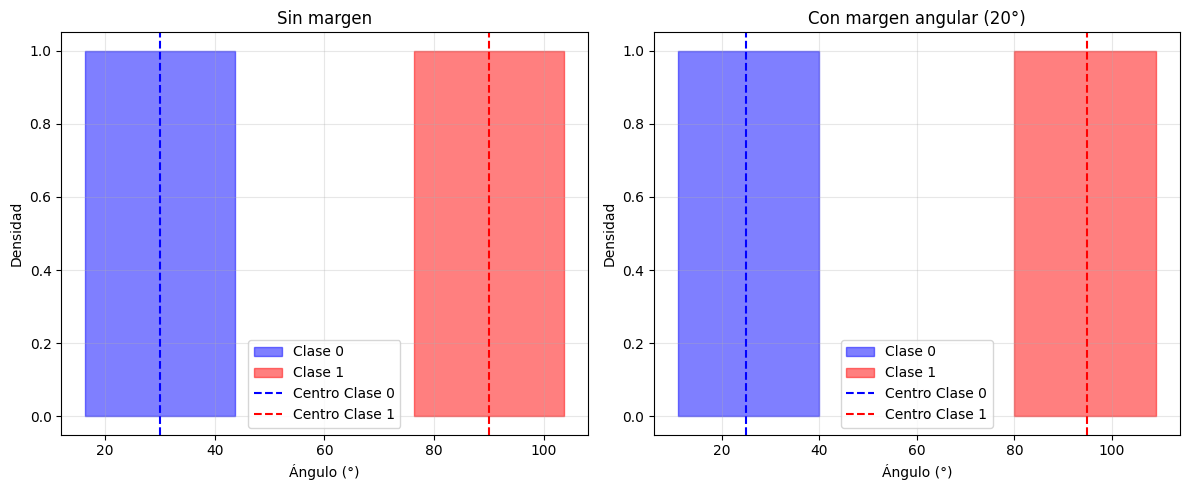

In [48]:
# Resultados sin margen
theta0_sin = 30
theta1_sin = 90

# Resultados con margen
theta0_con = 25
theta1_con = 95

# Crear figura
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Sin margen
ax = axes[0]
ang = np.linspace(0, 180, 100)
ax.fill_between(ang, 0, 1, where=(ang >= theta0_sin-15) & (ang <= theta0_sin+15),
                 color='blue', alpha=0.5, label='Clase 0')
ax.fill_between(ang, 0, 1, where=(ang >= theta1_sin-15) & (ang <= theta1_sin+15),
                 color='red', alpha=0.5, label='Clase 1')
ax.axvline(theta0_sin, color='blue', linestyle='--', label='Centro Clase 0')
ax.axvline(theta1_sin, color='red', linestyle='--', label='Centro Clase 1')
ax.set_xlabel('Ángulo (°)')
ax.set_ylabel('Densidad')
ax.set_title('Sin margen')
ax.legend()
ax.grid(True, alpha=0.3)

# Gráfico 2: Con margen
ax = axes[1]
ax.fill_between(ang, 0, 1, where=(ang >= theta0_con-15) & (ang <= theta0_con+15),
                 color='blue', alpha=0.5, label='Clase 0')
ax.fill_between(ang, 0, 1, where=(ang >= theta1_con-15) & (ang <= theta1_con+15),
                 color='red', alpha=0.5, label='Clase 1')
ax.axvline(theta0_con, color='blue', linestyle='--', label='Centro Clase 0')
ax.axvline(theta1_con, color='red', linestyle='--', label='Centro Clase 1')
ax.set_xlabel('Ángulo (°)')
ax.set_ylabel('Densidad')
ax.set_title('Con margen angular (20°)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Explicación: Con margen, las clases están más separadas (25° vs 95°). Esto reduce confusiones en el límite.

Conclusión: El margen angular fuerza una separación extra entre clases, haciendo el reconocimiento más preciso.